UNION PRUEBA-MODO ENSAMBLE

In [ ]:
# 1. Creamos una única puerta de entrada (Input) para que ambos modelos reciban la misma imagen
entrada_comun = Input(shape=(50, 50, 3), name='entrada_ensamble')

# 2. Pasamos la imagen por ambos modelos de forma paralela
salida_cnn = model_cnn(entrada_comun)
salida_eff = model_eff(entrada_comun)




# 3. Unimos las predicciones promediando sus resultados (Soft Voting)
salida_ensamble = Average(name='promedio_votacion')([salida_cnn, salida_eff])

# 4. Empaquetamos todo en un nuevo y único modelo final
modelo_ensamble = Model(inputs=entrada_comun, outputs=salida_ensamble, name='Ensamble_Cancer_Mama')

# 5. Compilamos el ensamble
# Usamos un learning_rate muy bajo porque solo queremos hacer un ajuste fino,
# no queremos destruir lo que los modelos base ya aprendieron.
modelo_ensamble.compile(optimizer=Adam(learning_rate=0.0001), 
                        loss='binary_crossentropy', 
                        metrics=['accuracy'])

print("¡Arquitectura de Ensamble creada con éxito!")
modelo_ensamble.summary()

1.EfficientNetB0
es una red neuronal convolucional (CNN) ligera y de alto rendimiento, diseñada para la clasificación de imágenes con alta precisión y baja carga computacional. Es el modelo base de la familia EfficientNet, entrenado con ImageNet (
 píxeles), utiliza escalado compuesto para optimizar profundidad, ancho y resolución simultáneamente, y emplea bloques MBConv con atención SE.

  Utiliza bloques de convolución móvil invertida (MBConv) con atención de canal Squeeze-and-Excitation (SE) y funciones de activación Swish/SiLU para mejorar el flujo de gradiente.
Escalado Compuesto: A diferencia del escalado simple, EfficientNet-B0 escala la profundidad, ancho y resolución de la red utilizando un coeficiente constante, optimizando el rendimiento.

Cargando dataset desde C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes\labels.csv...
Total de imágenes: 157572
Pacientes únicos: 279

--- Distribución de splits por paciente (patient_id) ---
Train: 105961 imgs (pacientes: 195)
Val:   26283 imgs (pacientes: 42)
Test:  25328 imgs (pacientes: 42)
Verificación de fuga de datos (Data Leakage) pasada: OK.

Preparando generador de Entrenamiento...
Found 105961 validated image filenames belonging to 2 classes.
Preparando generador de Validación...
Found 26283 validated image filenames belonging to 2 classes.
Preparando generador de Prueba...
Found 25328 validated image filenames belonging to 2 classes.

--- Fase 1: Congelando TODO el modelo base para preentrenamiento de la cabeza ---

>>> Iniciando Fase 1: Entrenando solo la parte superior...
Epoch 1/5
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 527s 315ms/step - accuracy: 0.5196 - loss: 0.6945 - val_accuracy: 0.6231 - val_loss: 0.6836
Epoch 2/5
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 497s


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

Negativo (0)       0.54      0.96      0.69     13167
Positivo (1)       0.71      0.12      0.20     12161

    accuracy                           0.55     25328
   macro avg       0.62      0.54      0.44     25328
weighted avg       0.62      0.55      0.45     25328

Gráfica de matriz de confusión guardada en 'confusion_matrix.png'


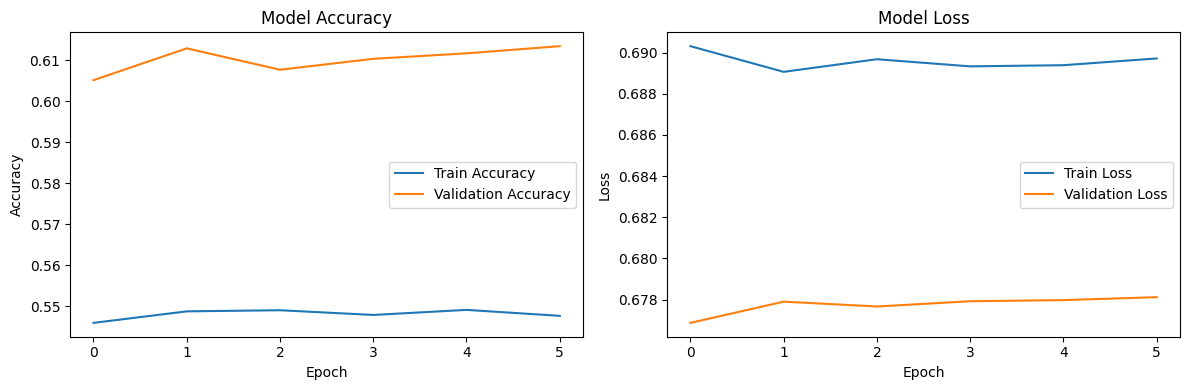

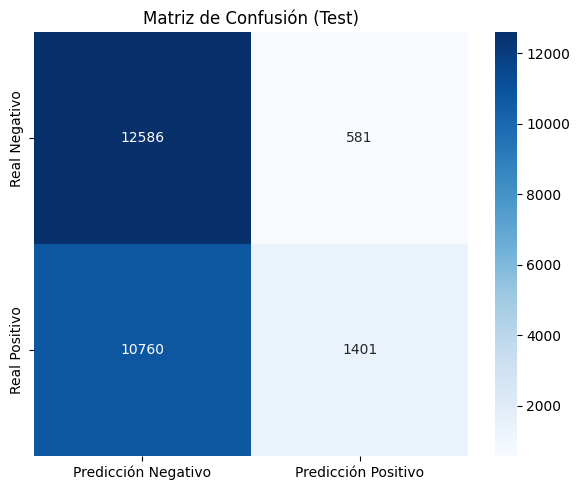

In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
BASE_DIR = r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes'

CSV_PATH = r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes\labels.csv'
IMG_SIZE = (50, 50)
BATCH_SIZE = 64
EPOCHS = 16# Configurado a 1 para prueba rápida, cambiar a 20 o más después




def load_and_split_data(csv_path, test_size=0.15, val_size=0.15):
    """
    Carga el CSV y divide los datos asegurando que todos los parches de un 
    mismo paciente (patient_id) estén estrictamente en uno de los conjuntos.
    """
    print(f"Cargando dataset desde {csv_path}...")
    df = pd.read_csv(csv_path)
    
    # Asegurarnos de que las clases son strings para ImageDataGenerator
    df['class'] = df['class'].astype(str)
    
    print(f"Total de imágenes: {len(df)}")
    print(f"Pacientes únicos: {df['patient_id'].nunique()}")

    # 1. Separar un conjunto de PRUEBA (Test)
    # GroupShuffleSplit asegura que los grupos (pacientes) no se mezclen.
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=42)
    
    train_val_idx, test_idx = next(gss_test.split(df, groups=df['patient_id']))
    df_train_val = df.iloc[train_val_idx].reset_index(drop=True)
    df_test = df.iloc[test_idx].reset_index(drop=True)

    # 2. Separar el restante en ENTRENAMIENTO y VALIDACIÓN
    # Calculamos la proporción de validación relativa al set restante
    # Si test_size es 0.15 y val_size es 0.15, val es ~0.176 del 0.85 restante
    val_relative_size = val_size / (1.0 - test_size)
    
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_relative_size, random_state=42)
    train_idx, val_idx = next(gss_val.split(df_train_val, groups=df_train_val['patient_id']))
    
    df_train = df_train_val.iloc[train_idx].reset_index(drop=True)
    df_val = df_train_val.iloc[val_idx].reset_index(drop=True)
    
    print("\n--- Distribución de splits por paciente (patient_id) ---")
    print(f"Train: {len(df_train)} imgs (pacientes: {df_train['patient_id'].nunique()})")
    print(f"Val:   {len(df_val)} imgs (pacientes: {df_val['patient_id'].nunique()})")
    print(f"Test:  {len(df_test)} imgs (pacientes: {df_test['patient_id'].nunique()})")
    
    # 3. Validar Fuga de Datos (Data Leakage)
    train_patients = set(df_train['patient_id'])
    val_patients = set(df_val['patient_id'])
    test_patients = set(df_test['patient_id'])
    
    assert len(train_patients.intersection(test_patients)) == 0, "¡FUGA DE DATOS entre Train y Test!"
    assert len(train_patients.intersection(val_patients)) == 0, "¡FUGA DE DATOS entre Train y Val!"
    print("Verificación de fuga de datos (Data Leakage) pasada: OK.\n")

    return df_train, df_val, df_test

def create_data_generators(df_train, df_val, df_test, base_dir):
    """Crea los generadores de imágenes (Image Data Generators) con Data Augmentation básico para predecir."""
    
    # Data Augmentation básico para entrenamiento
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
    )

    # Solo reescalado para validación y prueba
    test_datagen = ImageDataGenerator(rescale=1./255)

    print("Preparando generador de Entrenamiento...")
    train_generator = train_datagen.flow_from_dataframe(
        dataframe=df_train,
        directory=base_dir,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary"
    )

    print("Preparando generador de Validación...")
    val_generator = test_datagen.flow_from_dataframe(
        dataframe=df_val,
        directory=base_dir,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary"
    )

    print("Preparando generador de Prueba...")
    test_generator = test_datagen.flow_from_dataframe(
        dataframe=df_test,
        directory=base_dir,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False # IMPORTANTE: no mezclar test para comparar etiquetas
    )

    return train_generator, val_generator, test_generator

def build_model(freeze_base_model=True, dropout_rate=0.5):
    """
    Construye el modelo con EfficientNetB0 como base, añadiendo una nueva 'cabeza' clasificadora.
    Permite congelar el modelo base para el preentrenamiento de la cabeza.
    """
    # 1. Cargar el modelo base preentrenado sin la cabeza superior (include_top=False)
    # y con la resolución de tus imágenes (50, 50, 3).
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(50, 50, 3))
    
    # 2. Controlar la congelación del modelo base según el argumento.
    if freeze_base_model:
        # FASE 1: Congelamos todo el modelo base.
        print("\n--- Fase 1: Congelando TODO el modelo base para preentrenamiento de la cabeza ---")
        base_model.trainable = False
    else:
        # FASE 2: Descongelamos solo las capas superiores para el fine-tuning.
        # Ajustamos esto para que sea menos agresivo (últimas 20 capas).
        n_layers_to_unfreeze = 30
        print(f"\n--- Fase 2: Descongelando las últimas {n_layers_to_unfreeze} capas para fine-tuning ---")
        base_model.trainable = True
        # Volvemos a congelar todas menos las últimas 'n_layers_to_unfreeze' capas.
        for layer in base_model.layers[:-n_layers_to_unfreeze]:
            layer.trainable = False
            
    # 3. Construir la nueva 'cabeza' (clasificador superior).
    x = base_model.output
    
    # Añadimos BatchNormalization para estabilizar y acelerar el entrenamiento.
    x = BatchNormalization()(x)
    
    # GlobalAveragePooling2D reduce las dimensiones espaciales a vectores (512 en EfficientNetB0)
    # manteniendo la mayor información posible.
    x = GlobalAveragePooling2D()(x)
    
    # Añadimos Dropout para reducir el sobreajuste (overfitting).
    x = Dropout(dropout_rate)(x) 
    
    # Capa de salida para clasificación binaria (IDC o no IDC).
    predictions = Dense(1, activation='sigmoid')(x)

    # 4. Crear el modelo final.
    model_eff = Model(inputs=base_model.input, outputs=predictions)

    return model_eff


def plot_metrics(history):
    """Grafica la precisión y pérdida durante el entrenamiento."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    print("Gráfica de historial guardada en 'training_history.png'")
    # plt.show() # Descomentar para ver en notebook o entorno visual

def evaluate_model(model, test_generator):
    """Evalúa el modelo y genera el reporte de clasificación y matriz de confusión."""
    print("\nEvaluando el modelo en el conjunto de prueba...")
    
    # Calcular pasos requeridos para pasar todo el set de test exactamente una vez
    test_steps = int(np.ceil(test_generator.samples / test_generator.batch_size))
    
    # Obtener probabilidades
    predictions = model.predict(test_generator, steps=test_steps)
    y_pred = (predictions > 0.5).astype(int).reshape(-1)
    
    # Etiquetas reales
    y_true =  test_generator.classes
    
    # Nombres de las clases
    class_labels = list(test_generator.class_indices.keys())
    
    print("\n--- Reporte de Clasificación ---")
    print(classification_report(y_true, y_pred, target_names=["Negativo (0)", "Positivo (1)"]))
    
    # Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=["Predicción Negativo", "Predicción Positivo"],
                yticklabels=["Real Negativo", "Real Positivo"])
    plt.title('Matriz de Confusión (Test)')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    print("Gráfica de matriz de confusión guardada en 'confusion_matrix.png'")
    
if __name__ == "__main__":
    # 1. Cargar y dividir
    df_train, df_val, df_test = load_and_split_data(CSV_PATH)
    
    # 2. Generar dataloaders
    train_gen, val_gen, test_gen = create_data_generators(df_train, df_val, df_test, BASE_DIR)
    
    # Pesos de clases
    neg_count = sum(df_train['class'] == '0')
    pos_count = sum(df_train['class'] == '1')
    total = len(df_train)
    weight_0 = (1 / neg_count) * (total / 2.0)
    weight_1 = (1 / pos_count) * (total / 2.0)
    class_weights = {0: weight_0, 1: weight_1}

    # ==============================================================================
    # FASE 1: PREENTRENAMIENTO DE LA CABEZA
    # ==============================================================================
    model = build_model(freeze_base_model=True, dropout_rate=0.5)
    
    optimizer_p1 = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer_p1, loss='binary_crossentropy', metrics=['accuracy'])
    
    early_stop_phase1 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
    
    print("\n>>> Iniciando Fase 1: Entrenando solo la parte superior...")
    history_p1 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=5,
        class_weight=class_weights,
        callbacks=[early_stop_phase1]
    )
    
    # ==============================================================================
    # FASE 2: FINE-TUNING (SIN CARGAR ARCHIVOS)
    # ==============================================================================
    print("\n>>> Iniciando Fase 2: Fine-tuning de las últimas capas...")
    
    # Buscamos la capa que contiene a EfficientNet (usualmente se llama 'efficientnetb0')
    base_model_layer = None
    for layer in model.layers:
        if 'efficientnet' in layer.name.lower():
            base_model_layer = layer
            break

    if base_model_layer:
        base_model_layer.trainable = True
        # Congelamos todas menos las últimas 30 capas del modelo base
        for layer in base_model_layer.layers[:-50]:
            layer.trainable = False
        print("Capas de EfficientNet desbloqueadas correctamente.")
    else:
        print("ADVERTENCIA: No se encontró la capa base para desbloquear.")

    # RECOMPILAR es vital después de cambiar 'trainable'
    optimizer_p2 = Adam(learning_rate=1e-5) # Tasa muy pequeña
    model.compile(optimizer=optimizer_p2, loss='binary_crossentropy', metrics=['accuracy'])
    
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
    early_stop_phase2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
    
    history_p2 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS, 
        class_weight=class_weights,
        callbacks=[reduce_lr, early_stop_phase2]
    )
    
    # 6. Graficar y Evaluar
    plot_metrics(history_p2)
    evaluate_model(model, test_gen)
    # 7. Guardar el modelo
    model.save('idc_breast_cancer_model_final.h5')

Prueba MobileNetV2

Cargando dataset desde C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes\labels.csv...
Total de imágenes: 157572
Pacientes únicos: 279

--- Distribución de splits por paciente (patient_id) ---
Train: 105961 imgs (pacientes: 195)
Val:   26283 imgs (pacientes: 42)
Test:  25328 imgs (pacientes: 42)
Verificación de fuga de datos (Data Leakage) pasada: OK.

Preparando generador de Entrenamiento...
Found 105961 validated image filenames belonging to 2 classes.
Preparando generador de Validación...
Found 26283 validated image filenames belonging to 2 classes.
Preparando generador de Prueba...
Found 25328 validated image filenames belonging to 2 classes.

>>> FASE 1: Preentrenamiento de la cabeza (Modelo Base Congelado)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 292s 175ms/step - accuracy: 0.8223 - loss: 0.7392 - val_accuracy: 0.7821 - val_loss: 0.5678
Epoch 2/3
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 305s 184ms/step - accuracy: 0.8


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

Negativo (0)       0.94      0.78      0.85     13167
Positivo (1)       0.80      0.94      0.87     12161

    accuracy                           0.86     25328
   macro avg       0.87      0.86      0.86     25328
weighted avg       0.87      0.86      0.86     25328

Gráfica de matriz de confusión guardada en 'confusion_matrix.png'
Modelo guardado exitosamente como 'mobileNet.h5'


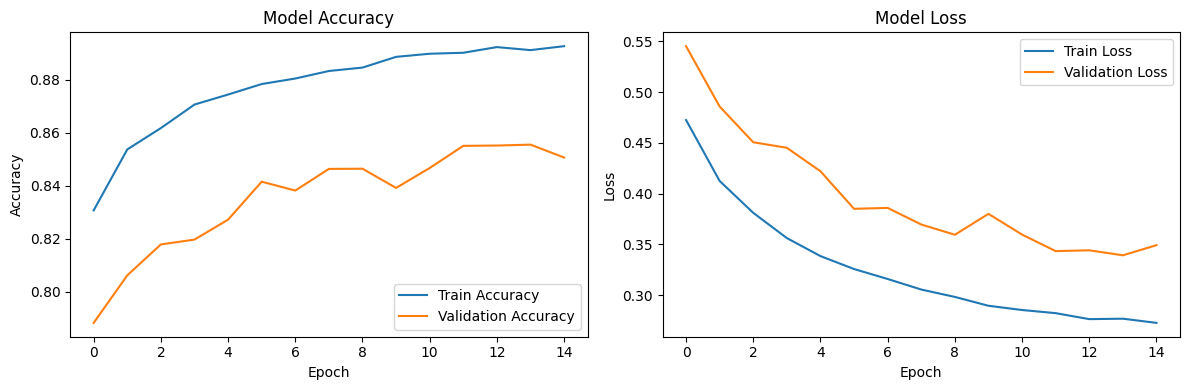

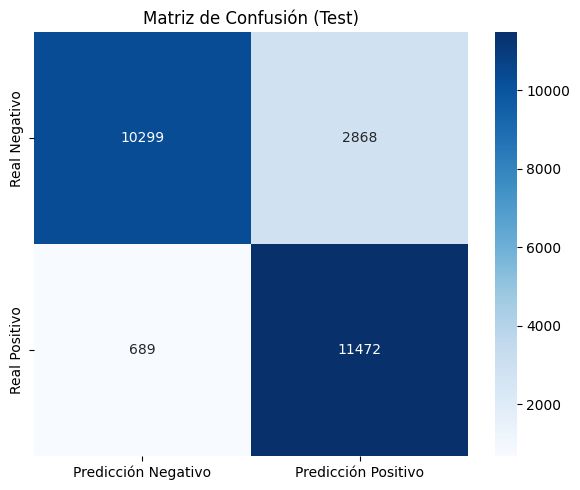

In [8]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input  # <-- IMPORTANTE: Preprocesamiento específico
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CONFIGURACIÓN
# ==========================================
BASE_DIR = r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes'
CSV_PATH = r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes\labels.csv'
IMG_SIZE = (96, 96)
BATCH_SIZE = 64
EPOCHS = 15  # Ajustado a 20 para realizar el entrenamiento completo

# ==========================================
# FUNCIONES DEL PIPELINE
# ==========================================

def load_and_split_data(csv_path, test_size=0.15, val_size=0.15):
    """
    Carga el CSV y divide los datos asegurando que todos los parches de un 
    mismo paciente (patient_id) estén estrictamente en uno de los conjuntos.
    """
    print(f"Cargando dataset desde {csv_path}...")
    df = pd.read_csv(csv_path)
    
    # Asegurarnos de que las clases son strings para ImageDataGenerator
    df['class'] = df['class'].astype(str)
    
    print(f"Total de imágenes: {len(df)}")
    print(f"Pacientes únicos: {df['patient_id'].nunique()}")

    # 1. Separar un conjunto de PRUEBA (Test)
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=42)
    
    train_val_idx, test_idx = next(gss_test.split(df, groups=df['patient_id']))
    df_train_val = df.iloc[train_val_idx].reset_index(drop=True)
    df_test = df.iloc[test_idx].reset_index(drop=True)

    # 2. Separar el restante en ENTRENAMIENTO y VALIDACIÓN
    val_relative_size = val_size / (1.0 - test_size)
    
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_relative_size, random_state=42)
    train_idx, val_idx = next(gss_val.split(df_train_val, groups=df_train_val['patient_id']))
    
    df_train = df_train_val.iloc[train_idx].reset_index(drop=True)
    df_val = df_train_val.iloc[val_idx].reset_index(drop=True)
    
    print("\n--- Distribución de splits por paciente (patient_id) ---")
    print(f"Train: {len(df_train)} imgs (pacientes: {df_train['patient_id'].nunique()})")
    print(f"Val:   {len(df_val)} imgs (pacientes: {df_val['patient_id'].nunique()})")
    print(f"Test:  {len(df_test)} imgs (pacientes: {df_test['patient_id'].nunique()})")
    
    # 3. Validar Fuga de Datos (Data Leakage)
    train_patients = set(df_train['patient_id'])
    val_patients = set(df_val['patient_id'])
    test_patients = set(df_test['patient_id'])
    
    assert len(train_patients.intersection(test_patients)) == 0, "¡FUGA DE DATOS entre Train y Test!"
    assert len(train_patients.intersection(val_patients)) == 0, "¡FUGA DE DATOS entre Train y Val!"
    print("Verificación de fuga de datos (Data Leakage) pasada: OK.\n")

    return df_train, df_val, df_test

def create_data_generators(df_train, df_val, df_test, base_dir):
    # Augmentation avanzado para tejido médico
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=40,
        width_shift_range=0.1, # Movimiento horizontal
        height_shift_range=0.1, # Movimiento vertical
        zoom_range=0.2, # Acercar/Alejar
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='reflect' # 'reflect' es ideal para imágenes continuas como tejido
    )

    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    print("Preparando generador de Entrenamiento...")
    train_generator = train_datagen.flow_from_dataframe(
        dataframe=df_train, directory=base_dir, x_col="filename", y_col="class",
        target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
    )

    print("Preparando generador de Validación...")
    val_generator = test_datagen.flow_from_dataframe(
        dataframe=df_val, directory=base_dir, x_col="filename", y_col="class",
        target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
    )

    print("Preparando generador de Prueba...")
    test_generator = test_datagen.flow_from_dataframe(
        dataframe=df_test, directory=base_dir, x_col="filename", y_col="class",
        target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
    )

    return train_generator, val_generator, test_generator



def build_model(freeze_all=True):
    """Construye modelo usando MobileNetV2"""
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    if freeze_all:
        base_model.trainable = False
    else:
        # Descongelamos las últimas 50 capas (más agresivo ahora que la imagen es más grande)
        base_model.trainable = True
        for layer in base_model.layers[:-50]:
            layer.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        # Añadimos regularización L2 para evitar overfitting con el accuracy tan alto
        Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model


def plot_metrics(history):
    """Grafica la precisión y pérdida durante el entrenamiento."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    print("Gráfica de historial guardada en 'training_history.png'")


def evaluate_model(model, test_generator):
    """Evalúa el modelo y genera el reporte de clasificación y matriz de confusión."""
    print("\nEvaluando el modelo en el conjunto de prueba...")
    
    test_steps = int(np.ceil(test_generator.samples / test_generator.batch_size))
    
    predictions = model.predict(test_generator, steps=test_steps)
    y_pred = (predictions > 0.5).astype(int).reshape(-1)
    
    y_true =  test_generator.classes
    class_labels = list(test_generator.class_indices.keys())
    
    print("\n--- Reporte de Clasificación ---")
    print(classification_report(y_true, y_pred, target_names=["Negativo (0)", "Positivo (1)"]))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=["Predicción Negativo", "Predicción Positivo"],
                yticklabels=["Real Negativo", "Real Positivo"])
    plt.title('Matriz de Confusión (Test)')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    print("Gráfica de matriz de confusión guardada en 'confusion_matrix.png'")

# ==========================================
# EJECUCIÓN PRINCIPAL
# ==========================================
if __name__ == "__main__":
    df_train, df_val, df_test = load_and_split_data(CSV_PATH)
    train_gen, val_gen, test_gen = create_data_generators(df_train, df_val, df_test, BASE_DIR)
    
    neg_count = sum(df_train['class'] == '0')
    pos_count = sum(df_train['class'] == '1')
    total = len(df_train)
    weight_0 = (1 / neg_count) * (total / 2.0)
    weight_1 = (1 / pos_count) * (total / 2.0)
    class_weights = {0: weight_0, 1: weight_1}

    # ======================================================
    # FASE 1: Entrenar solo la cabeza clasificadora (3 épocas)
    # ======================================================
    print("\n>>> FASE 1: Preentrenamiento de la cabeza (Modelo Base Congelado)")
    model = build_model(freeze_all=True)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    
    model.fit(
        train_gen, validation_data=val_gen, epochs=3, 
        class_weight=class_weights
    )

    # ======================================================
    # FASE 2: Fine-Tuning de las últimas 50 capas
    # ======================================================
    print("\n>>> FASE 2: Fine-Tuning profundo con Tasa de Aprendizaje Baja")
    
    # Buscamos la capa base y la descongelamos
    for layer in model.layers:
        if isinstance(layer, Model): # Si es el MobileNetV2
            layer.trainable = True
            for sub_layer in layer.layers[:-50]:
                sub_layer.trainable = False
            break

    # Compilamos con un learning rate 10 veces menor (1e-5) para ajustes finos
    model.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy'])
    
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS, # Aquí ya corre las épocas completas
        class_weight=class_weights,
        callbacks=[reduce_lr, early_stop]
    )
    
    plot_metrics(history)
    evaluate_model(model, test_gen)
    model.save('mobileNet.h5')
    print("Modelo guardado exitosamente como 'mobileNet.h5'")

In [ ]:
#describir base de datos
#arquitecturas a comparar, trabajos relacionados,
#resultados
#

ResNet

Cargando dataset desde C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes\labels.csv...
Total de imágenes: 157572
Pacientes únicos: 279

--- Distribución de splits por paciente (patient_id) ---
Train: 105961 imgs (pacientes: 195)
Val:   26283 imgs (pacientes: 42)
Test:  25328 imgs (pacientes: 42)
Verificación de fuga de datos (Data Leakage) pasada: OK.

Preparando generador de Entrenamiento...
Found 105961 validated image filenames belonging to 2 classes.
Preparando generador de Validación...
Found 26283 validated image filenames belonging to 2 classes.
Preparando generador de Prueba...
Found 25328 validated image filenames belonging to 2 classes.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 50, 50, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 50, 50,    │        896 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 50,    │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 50, 50,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 50,    │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 50, 50,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 25, 25,    │          0 │ add_2[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 25, 25,    │     18,496 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 25, 25,    │     36,928 │ conv2d_9[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 25,    │        256 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 25, 25,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 12, 12,    │          0 │ add_3[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 9216)      │          0 │ max_pooling2d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 512)       │  4,719,104 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 512)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │        513 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,785,697 (18.26 MB)

 Trainable params: 4,785,441 (18.26 MB)

 Non-trainable params: 256 (1.00 KB)


Pesos de clases: 0: 1.051, 1: 0.954

Iniciando entrenamiento...
Epoch 1/16
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 342s 206ms/step - accuracy: 0.8504 - loss: 0.4140 - val_accuracy: 0.8435 - val_loss: 0.3817 - learning_rate: 0.0010
Epoch 2/16
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 332s 200ms/step - accuracy: 0.8729 - loss: 0.3198 - val_accuracy: 0.6881 - val_loss: 0.8543 - learning_rate: 0.0010
Epoch 3/16
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.8782 - loss: 0.3040
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 331s 200ms/step - accuracy: 0.8796 - loss: 0.3010 - val_accuracy: 0.7371 - val_loss: 0.8689 - learning_rate: 0.0010
Epoch 4/16
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 330s 200ms/step - accuracy: 0.8907 - loss: 0.2704 - val_accuracy: 0.8440 - val_loss: 0.3684 - learning_rate: 5.0000e-04
Epoch 5/16
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 327s 198ms/step - accuracy: 0.8956 - loss: 0.2586 - val_accuracy: 0.8180 - val_loss: 0.4376 - learning


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

Negativo (0)       0.94      0.76      0.84     13167
Positivo (1)       0.78      0.95      0.86     12161

    accuracy                           0.85     25328
   macro avg       0.86      0.85      0.85     25328
weighted avg       0.87      0.85      0.85     25328

Gráfica de matriz de confusión guardada en 'confusion_matrix.png'
Modelo guardado exitosamente como 'model_resnet.h5'


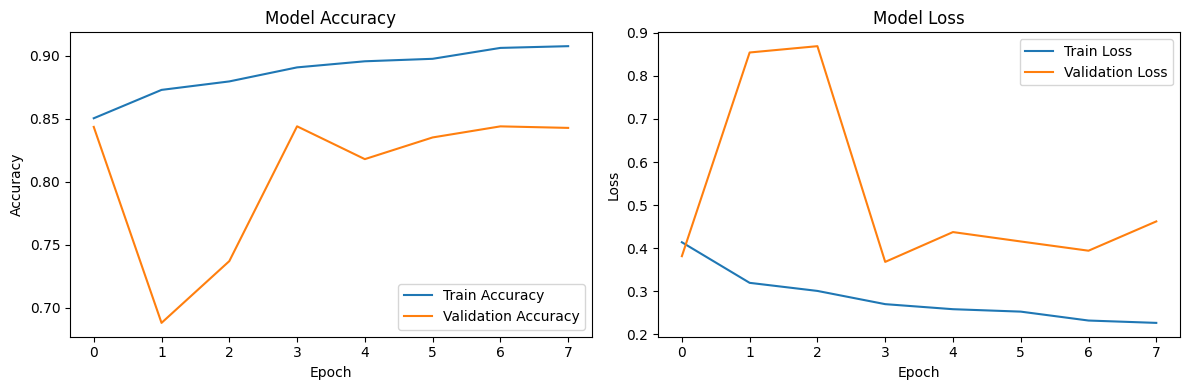

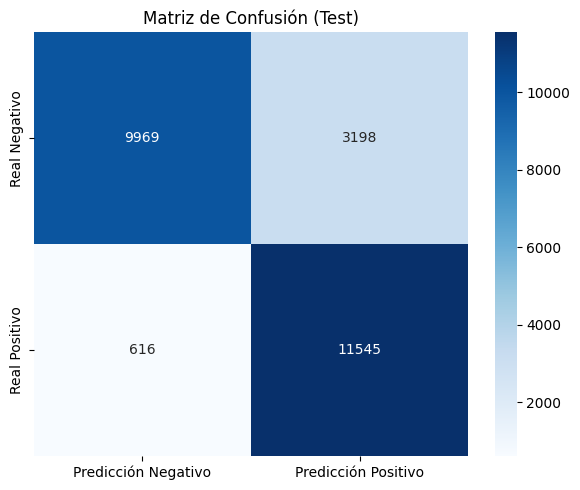

In [6]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import Add, Input
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
BASE_DIR = r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes'
CSV_PATH = r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes\labels.csv'
IMG_SIZE = (50, 50)
BATCH_SIZE = 64
EPOCHS = 16

def load_and_split_data(csv_path, test_size=0.15, val_size=0.15):
    """
    Carga el CSV y divide los datos asegurando que todos los parches de un 
    mismo paciente (patient_id) estén estrictamente en uno de los conjuntos.
    """
    print(f"Cargando dataset desde {csv_path}...")
    df = pd.read_csv(csv_path)
    
    # Asegurarnos de que las clases son strings para ImageDataGenerator
    df['class'] = df['class'].astype(str)
    
    print(f"Total de imágenes: {len(df)}")
    print(f"Pacientes únicos: {df['patient_id'].nunique()}")

    # 1. Separar un conjunto de PRUEBA (Test)
    # GroupShuffleSplit asegura que los grupos (pacientes) no se mezclen.
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=42)
    
    train_val_idx, test_idx = next(gss_test.split(df, groups=df['patient_id']))
    df_train_val = df.iloc[train_val_idx].reset_index(drop=True)
    df_test = df.iloc[test_idx].reset_index(drop=True)

    # 2. Separar el restante en ENTRENAMIENTO y VALIDACIÓN
    # Calculamos la proporción de validación relativa al set restante
    # Si test_size es 0.15 y val_size es 0.15, val es ~0.176 del 0.85 restante
    val_relative_size = val_size / (1.0 - test_size)
    
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_relative_size, random_state=42)
    train_idx, val_idx = next(gss_val.split(df_train_val, groups=df_train_val['patient_id']))
    
    df_train = df_train_val.iloc[train_idx].reset_index(drop=True)
    df_val = df_train_val.iloc[val_idx].reset_index(drop=True)
    
    print("\n--- Distribución de splits por paciente (patient_id) ---")
    print(f"Train: {len(df_train)} imgs (pacientes: {df_train['patient_id'].nunique()})")
    print(f"Val:   {len(df_val)} imgs (pacientes: {df_val['patient_id'].nunique()})")
    print(f"Test:  {len(df_test)} imgs (pacientes: {df_test['patient_id'].nunique()})")
    
    # 3. Validar Fuga de Datos (Data Leakage)
    train_patients = set(df_train['patient_id'])
    val_patients = set(df_val['patient_id'])
    test_patients = set(df_test['patient_id'])
    
    assert len(train_patients.intersection(test_patients)) == 0, "¡FUGA DE DATOS entre Train y Test!"
    assert len(train_patients.intersection(val_patients)) == 0, "¡FUGA DE DATOS entre Train y Val!"
    print("Verificación de fuga de datos (Data Leakage) pasada: OK.\n")

    return df_train, df_val, df_test

def create_data_generators(df_train, df_val, df_test, base_dir):
    """Crea los generadores de imágenes (Image Data Generators) con Data Augmentation básico para predecir."""
    
    # Data Augmentation básico para entrenamiento
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
    )

    # Solo reescalado para validación y prueba
    test_datagen = ImageDataGenerator(rescale=1./255)

    print("Preparando generador de Entrenamiento...")
    train_generator = train_datagen.flow_from_dataframe(
        dataframe=df_train,
        directory=base_dir,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary"
    )

    print("Preparando generador de Validación...")
    val_generator = test_datagen.flow_from_dataframe(
        dataframe=df_val,
        directory=base_dir,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary"
    )

    print("Preparando generador de Prueba...")
    test_generator = test_datagen.flow_from_dataframe(
        dataframe=df_test,
        directory=base_dir,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False # IMPORTANTE: no mezclar test para comparar etiquetas
    )

    return train_generator, val_generator, test_generator

# Asegúrate de agregar estos nuevos imports al inicio de tu archivo

def build_model():
    """Método: Red con Conexiones Residuales para mayor profundidad"""
    inputs = Input(shape=(50, 50, 3))
    
    # Capa Inicial
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    
    # Bloque Residual 1
    shortcut = x
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Add()([x, shortcut]) # Aquí ocurre el 'salto' que lo hace diferente
    x = MaxPooling2D((2, 2))(x)
    
    # Bloque Residual 2 (más filtros)
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    shortcut = x
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Add()([x, shortcut])
    x = MaxPooling2D((2, 2))(x)
    
    # Clasificador Final
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def plot_metrics(history):
    """Grafica la precisión y pérdida durante el entrenamiento."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    print("Gráfica de historial guardada en 'training_history.png'")
    # plt.show() # Descomentar para ver en notebook o entorno visual

def evaluate_model(model, test_generator):
    """Evalúa el modelo y genera el reporte de clasificación y matriz de confusión."""
    print("\nEvaluando el modelo en el conjunto de prueba...")
    
    # Calcular pasos requeridos para pasar todo el set de test exactamente una vez
    test_steps = int(np.ceil(test_generator.samples / test_generator.batch_size))
    
    # Obtener probabilidades
    predictions = model.predict(test_generator, steps=test_steps)
    y_pred = (predictions > 0.5).astype(int).reshape(-1)
    
    # Etiquetas reales
    y_true =  test_generator.classes
    
    # Nombres de las clases
    class_labels = list(test_generator.class_indices.keys())
    
    print("\n--- Reporte de Clasificación ---")
    print(classification_report(y_true, y_pred, target_names=["Negativo (0)", "Positivo (1)"]))
    
    # Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=["Predicción Negativo", "Predicción Positivo"],
                yticklabels=["Real Negativo", "Real Positivo"])
    plt.title('Matriz de Confusión (Test)')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    print("Gráfica de matriz de confusión guardada en 'confusion_matrix.png'")
    

if __name__ == "__main__":
    # 1. Cargar y dividir
    df_train, df_val, df_test = load_and_split_data(CSV_PATH)
    
    # 2. Generar dataloaders
    train_gen, val_gen, test_gen = create_data_generators(df_train, df_val, df_test, BASE_DIR)
    
    # 3. Construir modelo
    model = build_model()
    model.summary()
    
    # 4. Callbacks de entrenamiento
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
    early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
    
    # Cálculo de pesos para balancear la clase si es necesario (el dataset original es balanceado, pero el split puede variar levemente)
    neg_count = sum(df_train['class'] == '0')
    pos_count = sum(df_train['class'] == '1')
    total = len(df_train)
    weight_0 = (1 / neg_count) * (total / 2.0)
    weight_1 = (1 / pos_count) * (total / 2.0)
    class_weights = {0: weight_0, 1: weight_1}
    print(f"\nPesos de clases: 0: {weight_0:.3f}, 1: {weight_1:.3f}\n")

    # 5. Entrenar (Configurado EPOCHS a 1 solo para probar rápido. Cambiar a 20 o más después)
    # Por defecto está a EPOCHS (20) en las constantes arriba.
    print("Iniciando entrenamiento...")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=[reduce_lr, early_stop]
    )
    
    # 6. Graficar y Evaluar
    plot_metrics(history)
    evaluate_model(model, test_gen)
    
    # 7. Guardar el modelo
    model.save('model_resnet.h5')
    print("Modelo guardado exitosamente como 'model_resnet.h5'")

red neuronal CNN

Cargando dataset desde C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes\labels.csv...
Total de imágenes: 157572
Pacientes únicos: 279

--- Distribución de splits por paciente (patient_id) ---
Train: 105961 imgs (pacientes: 195)
Val:   26283 imgs (pacientes: 42)
Test:  25328 imgs (pacientes: 42)
Verificación de fuga de datos (Data Leakage) pasada: OK.

Preparando generador de Entrenamiento...
Found 105961 validated image filenames belonging to 2 classes.
Preparando generador de Validación...
Found 26283 validated image filenames belonging to 2 classes.
Preparando generador de Prueba...
Found 25328 validated image filenames belonging to 2 classes.


c:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 22, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 9, 9, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 618,945 (2.36 MB)

 Trainable params: 618,497 (2.36 MB)

 Non-trainable params: 448 (1.75 KB)


Pesos de clases: 0: 1.051, 1: 0.954

Iniciando entrenamiento...
Epoch 1/16
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 141s 84ms/step - accuracy: 0.8391 - loss: 0.3929 - val_accuracy: 0.7668 - val_loss: 0.6275 - learning_rate: 0.0010
Epoch 2/16
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 143s 86ms/step - accuracy: 0.8613 - loss: 0.3402 - val_accuracy: 0.5551 - val_loss: 1.0913 - learning_rate: 0.0010
Epoch 3/16
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8693 - loss: 0.3286
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 142s 86ms/step - accuracy: 0.8716 - loss: 0.3206 - val_accuracy: 0.6169 - val_loss: 0.9484 - learning_rate: 0.0010
Epoch 4/16
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 144s 87ms/step - accuracy: 0.8807 - loss: 0.2906 - val_accuracy: 0.8376 - val_loss: 0.4044 - learning_rate: 5.0000e-04
Epoch 5/16
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 143s 86ms/step - accuracy: 0.8848 - loss: 0.2828 - val_accuracy: 0.8219 - val_loss: 0.4303 - learning_rate:

Gráfica de matriz de confusión guardada en 'confusion_matrix.png'
Modelo guardado exitosamente como 'model_cnn.h5'


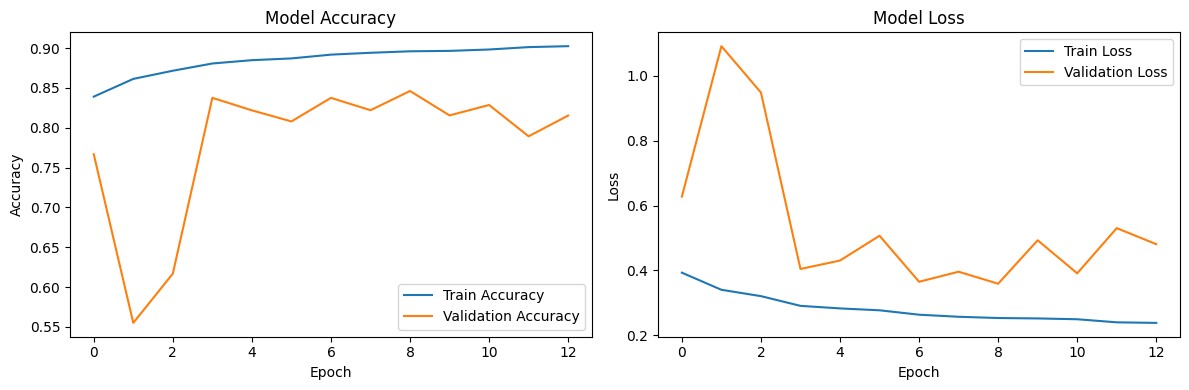

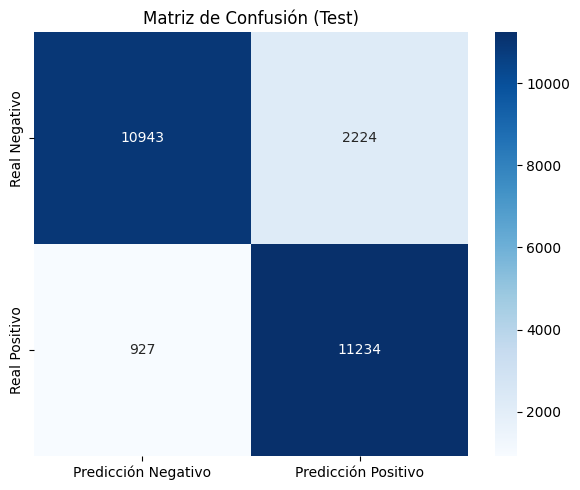

In [9]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
BASE_DIR = r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes'
CSV_PATH = os.path.join(BASE_DIR, 'labels.csv')
IMG_SIZE = (50, 50)
BATCH_SIZE = 64
EPOCHS = 16

def load_and_split_data(csv_path, test_size=0.15, val_size=0.15):
    """
    Carga el CSV y divide los datos asegurando que todos los parches de un 
    mismo paciente (patient_id) estén estrictamente en uno de los conjuntos.
    """
    print(f"Cargando dataset desde {csv_path}...")
    df = pd.read_csv(csv_path)
    
    # Asegurarnos de que las clases son strings para ImageDataGenerator
    df['class'] = df['class'].astype(str)
    
    print(f"Total de imágenes: {len(df)}")
    print(f"Pacientes únicos: {df['patient_id'].nunique()}")

    # 1. Separar un conjunto de PRUEBA (Test)
    # GroupShuffleSplit asegura que los grupos (pacientes) no se mezclen.
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=42)
    
    train_val_idx, test_idx = next(gss_test.split(df, groups=df['patient_id']))
    df_train_val = df.iloc[train_val_idx].reset_index(drop=True)
    df_test = df.iloc[test_idx].reset_index(drop=True)

    # 2. Separar el restante en ENTRENAMIENTO y VALIDACIÓN
    # Calculamos la proporción de validación relativa al set restante
    # Si test_size es 0.15 y val_size es 0.15, val es ~0.176 del 0.85 restante
    val_relative_size = val_size / (1.0 - test_size)
    
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_relative_size, random_state=42)
    train_idx, val_idx = next(gss_val.split(df_train_val, groups=df_train_val['patient_id']))
    
    df_train = df_train_val.iloc[train_idx].reset_index(drop=True)
    df_val = df_train_val.iloc[val_idx].reset_index(drop=True)
    
    print("\n--- Distribución de splits por paciente (patient_id) ---")
    print(f"Train: {len(df_train)} imgs (pacientes: {df_train['patient_id'].nunique()})")
    print(f"Val:   {len(df_val)} imgs (pacientes: {df_val['patient_id'].nunique()})")
    print(f"Test:  {len(df_test)} imgs (pacientes: {df_test['patient_id'].nunique()})")
    
    # 3. Validar Fuga de Datos (Data Leakage)
    train_patients = set(df_train['patient_id'])
    val_patients = set(df_val['patient_id'])
    test_patients = set(df_test['patient_id'])
    
    assert len(train_patients.intersection(test_patients)) == 0, "¡FUGA DE DATOS entre Train y Test!"
    assert len(train_patients.intersection(val_patients)) == 0, "¡FUGA DE DATOS entre Train y Val!"
    print("Verificación de fuga de datos (Data Leakage) pasada: OK.\n")

    return df_train, df_val, df_test

def create_data_generators(df_train, df_val, df_test, base_dir):
    """Crea los generadores de imágenes (Image Data Generators) con Data Augmentation básico para predecir."""
    
    # Data Augmentation básico para entrenamiento
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
    )

    # Solo reescalado para validación y prueba
    test_datagen = ImageDataGenerator(rescale=1./255)

    print("Preparando generador de Entrenamiento...")
    train_generator = train_datagen.flow_from_dataframe(
        dataframe=df_train,
        directory=base_dir,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary"
    )

    print("Preparando generador de Validación...")
    val_generator = test_datagen.flow_from_dataframe(
        dataframe=df_val,
        directory=base_dir,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary"
    )

    print("Preparando generador de Prueba...")
    test_generator = test_datagen.flow_from_dataframe(
        dataframe=df_test,
        directory=base_dir,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False # IMPORTANTE: no mezclar test para comparar etiquetas
    )

    return train_generator, val_generator, test_generator

def build_model():
    """Construye y compila el modelo CNN"""
    model = Sequential([
        # Bloque 1
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        # Bloque 2
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        # Bloque 3
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        
        # Clasificador Fully Connected
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid') # Clasificación Binaria
    ])
    
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=['accuracy']
    )
    
    return model

def plot_metrics(history):
    """Grafica la precisión y pérdida durante el entrenamiento."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    print("Gráfica de historial guardada en 'training_history.png'")
    # plt.show() # Descomentar para ver en notebook o entorno visual

def evaluate_model(model, test_generator):
    """Evalúa el modelo y genera el reporte de clasificación y matriz de confusión."""
    print("\nEvaluando el modelo en el conjunto de prueba...")
    
    # Calcular pasos requeridos para pasar todo el set de test exactamente una vez
    test_steps = int(np.ceil(test_generator.samples / test_generator.batch_size))
    
    # Obtener probabilidades
    predictions = model.predict(test_generator, steps=test_steps)
    y_pred = (predictions > 0.5).astype(int).reshape(-1)
    
    # Etiquetas reales
    y_true =  test_generator.classes
    
    # Nombres de las clases
    class_labels = list(test_generator.class_indices.keys())
    
    print("\n--- Reporte de Clasificación ---")
    print(classification_report(y_true, y_pred, target_names=["Negativo (0)", "Positivo (1)"]))
    
    # Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=["Predicción Negativo", "Predicción Positivo"],
                yticklabels=["Real Negativo", "Real Positivo"])
    plt.title('Matriz de Confusión (Test)')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    print("Gráfica de matriz de confusión guardada en 'confusion_matrix.png'")
    

if __name__ == "__main__":
    # 1. Cargar y dividir
    df_train, df_val, df_test = load_and_split_data(CSV_PATH)
    
    # 2. Generar dataloaders
    train_gen, val_gen, test_gen = create_data_generators(df_train, df_val, df_test, BASE_DIR)
    
    # 3. Construir modelo
    model = build_model()
    model.summary()
    
    # 4. Callbacks de entrenamiento
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
    early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
    
    # Cálculo de pesos para balancear la clase si es necesario (el dataset original es balanceado, pero el split puede variar levemente)
    neg_count = sum(df_train['class'] == '0')
    pos_count = sum(df_train['class'] == '1')
    total = len(df_train)
    weight_0 = (1 / neg_count) * (total / 2.0)
    weight_1 = (1 / pos_count) * (total / 2.0)
    class_weights = {0: weight_0, 1: weight_1}
    print(f"\nPesos de clases: 0: {weight_0:.3f}, 1: {weight_1:.3f}\n")

    # 5. Entrenar (Configurado EPOCHS a 1 solo para probar rápido. Cambiar a 20 o más después)
    # Por defecto está a EPOCHS (20) en las constantes arriba.
    print("Iniciando entrenamiento...")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=[reduce_lr, early_stop]
    )
    
    # 6. Graficar y Evaluar
    plot_metrics(history)
    evaluate_model(model, test_gen)
    
    # 7. Guardar el modelo
    model.save('model_cnn.h5')
    print("Modelo guardado exitosamente como 'model_cnn.h5'")

Modelo Ensamble

In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CONFIGURACIÓN
# ==========================================
BASE_DIR = r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes'
CSV_PATH = r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes\labels.csv'
IMG_SIZE = (50, 50) 
BATCH_SIZE = 64

def evaluate_ensemble():
    # 1. Cargar el dataframe de Test (Asumimos que usas la misma lógica de split)
    # Aquí simplificamos para cargar solo los datos. 
    # IMPORTANTE: Asegúrate de que el df_test sea exactamente el mismo que usaste al entrenar.
    # (Puedes guardar df_test en un CSV durante el entrenamiento para cargarlo directamente aquí)
    print("Cargando datos...")
    df = pd.read_csv(CSV_PATH)
    df['class'] = df['class'].astype(str)
    
    # Para este ejemplo, simulamos que pasas todo tu df_test real
    # Reemplaza 'df' por tu 'df_test' real generado por load_and_split_data
    df_test = df # <--- CAMBIAR POR TU DF_TEST REAL
    
    # 2. Crear generador SIN preprocesamiento (entregará píxeles crudos 0-255)
    # Esto es vital para poder aplicar los diferentes preprocesamientos luego
    raw_datagen = ImageDataGenerator() 
    
    test_generator = raw_datagen.flow_from_dataframe(
        dataframe=df_test,
        directory=BASE_DIR,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False # Vital que sea False para mantener el orden
    )

    # 3. Cargar los 3 modelos guardados
    print("Cargando modelos...")
    # Asegúrate de haber guardado tus modelos con estos nombres
    model_cnn = load_model('model_cnn.h5')
    model_resnet = load_model('model_resnet.h5')
    model_mobilenet = load_model('mobileNet.h5')

    ensemble_predictions = []
    real_labels = []

    print("Generando predicciones del Ensamble...")
    # 4. Iterar sobre los batches
    test_steps = int(np.ceil(test_generator.samples / BATCH_SIZE))
    
    for i in range(test_steps):
        # Obtener batch de imágenes crudas y sus etiquetas
        batch_x, batch_y = next(test_generator)
        real_labels.extend(batch_y)
        
        # Preprocesamiento A: Para CNN y ResNet (dividir entre 255)
        batch_x_standard = batch_x / 255.0
        
        # Preprocesamiento B: Para MobileNetV2 (usar su función propia)
        # Hacemos una copia para no alterar batch_x
        batch_x_mobile = mobilenet_preprocess(np.copy(batch_x))
        
        # Obtener predicciones (probabilidades)
        pred_cnn = model_cnn.predict_on_batch(batch_x_standard)
        pred_resnet = model_resnet.predict_on_batch(batch_x_standard)
        pred_mobile = model_mobilenet.predict_on_batch(batch_x_mobile)
        
        # SOFT VOTING: Promediar las tres probabilidades
        batch_ensemble_pred = (pred_cnn + pred_resnet + pred_mobile) / 3.0
        
        # Convertir a 0 o 1
        batch_final_class = (batch_ensemble_pred > 0.5).astype(int).reshape(-1)
        ensemble_predictions.extend(batch_final_class)
        
        print(f"Procesado batch {i+1}/{test_steps}")

    # 5. Evaluar Resultados Finales
    y_true = np.array(real_labels)
    y_pred = np.array(ensemble_predictions)
    
    print("\n=== REPORTE DE CLASIFICACIÓN DEL ENSAMBLE ===")
    print(classification_report(y_true, y_pred, target_names=["Negativo (0)", "Positivo (1)"]))
    
    # Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=["Predicción Negativo", "Predicción Positivo"],
                yticklabels=["Real Negativo", "Real Positivo"])
    plt.title('Matriz de Confusión (Ensamble de 3 Modelos)')
    plt.tight_layout()
    plt.savefig('confusion_matrix_ensemble.png')
    print("Gráfica guardada como 'confusion_matrix_ensemble.png'")

if __name__ == "__main__":
    evaluate_ensemble()

Cargando datos...
Found 157572 validated image filenames belonging to 2 classes.
Cargando modelos...


Generando predicciones del Ensamble...


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'input_layer_7' of layer 'mobilenetv2_1.00_96' is incompatible with the layer: expected shape=(None, 96, 96, 3), found shape=(64, 50, 50, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(64, 50, 50, 3), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [14]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Carga de datos de prueba
df_train, df_val, df_test = load_and_split_data(CSV_PATH)
_, _, test_gen = create_data_generators(df_train, df_val, df_test, BASE_DIR)

print("\nCargando modelos para el ensamble...")
m_axel = tf.keras.models.load_model(r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\model_resnet.h5')
m_david = tf.keras.models.load_model(r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\mobileNet.h5')
m_gabriel = tf.keras.models.load_model(r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\model_cnn.h5')

# Generar predicciones individuales
print("Generando predicciones (esto tomará unos segundos)...")
p_axel = m_axel.predict(test_gen)
p_david = m_david.predict(test_gen)
p_gabriel = m_gabriel.predict(test_gen)

y_true = test_gen.classes

# Reporte de AUC Individual
auc_a = roc_auc_score(y_true, p_axel)
auc_d = roc_auc_score(y_true, p_david)
auc_g = roc_auc_score(y_true, p_gabriel)

print(f"\n--- Resultados de AUC individuales ---")
print(f"Axel: {auc_a:.4f} | David: {auc_d:.4f} | Gabriel: {auc_g:.4f}")

print("\nConfigurando Ensamble Optimizado para Recall...")

# Pesos manuales (45/45/10)
w_a = 0.45
w_g = 0.45
w_d = 0.10 

# Umbral de decisión 
umbral = 0.38

print(f"Pesos: Axel({w_a}), Gabriel({w_g}), David({w_d})")
print(f"Umbral de detección: {umbral}")

# Fórmula del promedio ponderado
pred_final_prob = (p_axel * w_a) + (p_david * w_d) + (p_gabriel * w_g)

# Aplicación del umbral para el veredicto final
y_pred_final = (pred_final_prob > umbral).astype(int).reshape(-1)

# Evaluación Final y Matriz de Confusión
print("\n--- REPORTE FINAL DEL ENSAMBLAJE (UMBRAL 0.35) ---")
print(classification_report(y_true, y_pred_final, target_names=["Negativo (0)", "Positivo (1)"]))

cm = confusion_matrix(y_true, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title(f'Matriz de Confusión - Ensamble Manual (Umbral {umbral})')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Ensamble')
plt.savefig('confusion_matrix_UMBRAL_BAJO.png')

print(f"\n¡Listo! Matriz guardada como 'confusion_matrix_UMBRAL_BAJO.png'")
print(f"Falsos Negativos (Casos perdidos): {cm[1][0]}")
print(f"Falsos Positivos (Falsas alarmas): {cm[0][1]}")

Cargando dataset desde C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes\labels.csv...
Total de imágenes: 157572
Pacientes únicos: 279

--- Distribución de splits por paciente (patient_id) ---
Train: 105961 imgs (pacientes: 195)
Val:   26283 imgs (pacientes: 42)
Test:  25328 imgs (pacientes: 42)
Verificación de fuga de datos (Data Leakage) pasada: OK.

Preparando generador de Entrenamiento...
Found 105961 validated image filenames belonging to 2 classes.
Preparando generador de Validación...
Found 26283 validated image filenames belonging to 2 classes.
Preparando generador de Prueba...
Found 25328 validated image filenames belonging to 2 classes.



Cargando modelos para el ensamble...


Generando predicciones (esto tomará unos segundos)...
396/396 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'input_layer_7' of layer 'mobilenetv2_1.00_96' is incompatible with the layer: expected shape=(None, 96, 96, 3), found shape=(64, 50, 50, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(64, 50, 50, 3), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

prueba 0.4


Cargando dataset desde C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes\labels.csv...
Total de imágenes: 157572
Pacientes únicos: 279

--- Distribución de splits por paciente (patient_id) ---
Train: 105961 imgs (pacientes: 195)
Val:   26283 imgs (pacientes: 42)
Test:  25328 imgs (pacientes: 42)
Verificación de fuga de datos (Data Leakage) pasada: OK.


Preparando Generadores Especializados...
Found 25328 validated image filenames belonging to 2 classes.
Found 25328 validated image filenames belonging to 2 classes.



Cargando modelos para el ensamble...


Generando predicciones (esto tomará unos segundos)...
396/396 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step
396/396 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step
396/396 ━━━━━━━━━━━━━━━━━━━━ 38s 94ms/step

--- Resultados de AUC individuales ---
Axel (ResNet): 0.9508 | David (MobileNet): 0.9484 | Gabriel (CNN): 0.9533

Configurando Ensamble Optimizado para Recall...
Pesos: Axel(0.45), Gabriel(0.45), David(0.1)
Umbral de detección: 0.4

--- REPORTE FINAL DEL ENSAMBLAJE (UMBRAL 0.4) ---
              precision    recall  f1-score   support

Negativo (0)       0.96      0.75      0.84     13167
Positivo (1)       0.78      0.96      0.86     12161

    accuracy                           0.85     25328
   macro avg       0.87      0.86      0.85     25328
weighted avg       0.87      0.85      0.85     25328


¡Listo! Matriz guardada como 'confusion_matrix_UMBRAL_BAJO.png'
Falsos Negativos (Casos perdidos): 448
Falsos Positivos (Falsas alarmas): 3284


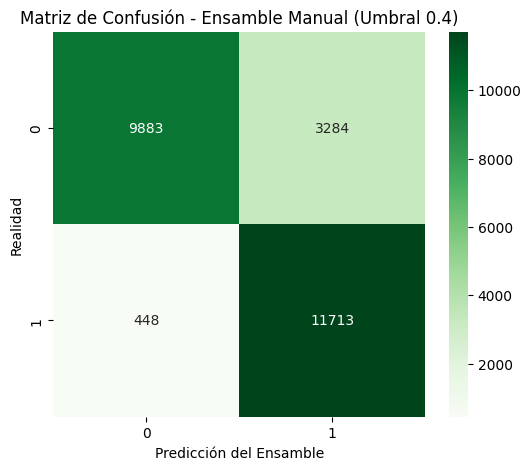

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess


BASE_DIR = r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes'
CSV_PATH = r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\Imagenes\labels.csv'

df_train, df_val, df_test = load_and_split_data(CSV_PATH)

print("\nPreparando Generadores Especializados...")

# 1. Generador para ResNet y CNN (50x50 y rescale)
datagen_50 = ImageDataGenerator(rescale=1./255)
test_gen_50 = datagen_50.flow_from_dataframe(
    dataframe=df_test, directory=BASE_DIR, x_col="filename", y_col="class",
    target_size=(50, 50), batch_size=64, class_mode="binary", shuffle=False
)

# 2. Generador para MobileNet (96x96 y preprocess_input)
datagen_96 = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)
test_gen_96 = datagen_96.flow_from_dataframe(
    dataframe=df_test, directory=BASE_DIR, x_col="filename", y_col="class",
    target_size=(96, 96), batch_size=64, class_mode="binary", shuffle=False
)

print("\nCargando modelos para el ensamble...")
m_axel = tf.keras.models.load_model(r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\model_resnet.h5')
m_david = tf.keras.models.load_model(r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\mobileNet.h5') 
m_gabriel = tf.keras.models.load_model(r'C:\Users\spide\Downloads\Alex\Rcodes\Course_Samsung\IDC-Net-main\model_cnn.h5')

# Generar predicciones individuales (¡Cada uno con su generador correspondiente!)
print("Generando predicciones (esto tomará unos segundos)...")
p_axel = m_axel.predict(test_gen_50)
p_gabriel = m_gabriel.predict(test_gen_50)
p_david = m_david.predict(test_gen_96) # <--- Aquí usamos el de 96x96

y_true = test_gen_50.classes # Las clases reales son las mismas en ambos generadores

# Reporte de AUC Individual
auc_a = roc_auc_score(y_true, p_axel)
auc_d = roc_auc_score(y_true, p_david)
auc_g = roc_auc_score(y_true, p_gabriel)

print(f"\n--- Resultados de AUC individuales ---")
print(f"Axel (ResNet): {auc_a:.4f} | David (MobileNet): {auc_d:.4f} | Gabriel (CNN): {auc_g:.4f}")

print("\nConfigurando Ensamble Optimizado para Recall...")
#pesos
w_a = 0.45
w_g = 0.45
w_d = 0.10 

# Umbral de decisión 
umbral = 0.40

print(f"Pesos: Axel({w_a}), Gabriel({w_g}), David({w_d})")
print(f"Umbral de detección: {umbral}")

# Fórmula del promedio ponderado
pred_final_prob = (p_axel * w_a) + (p_david * w_d) + (p_gabriel * w_g)

# Aplicación del umbral para el veredicto final
y_pred_final = (pred_final_prob > umbral).astype(int).reshape(-1)

# Evaluación Final y Matriz de Confusión
print(f"\n--- REPORTE FINAL DEL ENSAMBLAJE (UMBRAL {umbral}) ---")
print(classification_report(y_true, y_pred_final, target_names=["Negativo (0)", "Positivo (1)"]))

cm = confusion_matrix(y_true, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title(f'Matriz de Confusión - Ensamble Manual (Umbral {umbral})')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Ensamble')
plt.savefig('confusion_matrix_UMBRAL_BAJO.png')

print(f"\n¡Listo! Matriz guardada como 'confusion_matrix_UMBRAL_BAJO.png'")
print(f"Falsos Negativos (Casos perdidos): {cm[1][0]}")
print(f"Falsos Positivos (Falsas alarmas): {cm[0][1]}")